# PyDoseRT proton inverse planning on a simple water patient

**Author:** Attila Simkó

This example shows how we can optimize a simple proton treatment plan with PyDoseRT in four steps:

1. Load a reference patient geometry and structure set,
2. Place a pencil-beam spot grid and initialize the ion dose engine,
3. Define the optimization objective,
4. Run spot optimization and monitor the evolving dose distribution.

Compared to the photon example, the plan is no longer a sequence of shaped apertures. A proton plan is a
list of **spots**, each with a gantry angle, a lateral position, an energy and a weight, and the dose is
built by summing them. Everything except the gantry angles is optimized here: weights, spot positions,
energies and spot sizes all receive gradients from the dose.

Our goal here was not to **optimize the optimization**. There was no thorough hyperparameter tuning, the number of epochs could possibly be reduced significantly. Instead, here we only show how to use a simple optimization setup with PyDoseRT.


In [1]:
try:
    import pydosert
    print("pydosert is already installed")
except ImportError:
    !pip install pydosert

import math
import numpy as np
import torch
import matplotlib.pyplot as plt
import urllib.request
from dataclasses import replace
from pathlib import Path
from IPython.display import clear_output
import torch.nn.functional as F
from scipy.ndimage import map_coordinates

import pydosert as PDRT
from pydosert.data.ion_beam import IonBeamletBatch
from pydosert.utils.plotting import overlay_mask_outline, plot_overview
from pydosert.physics.kernels.ion_kernel_table import IonKernelTable
from pydosert.objectives.losses import upper_penalty

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.float32


pydosert is already installed


## Load a reference dataset

We use a simple patient-like water phantom with predefined structures.
The dataset contains structure labels that we convert into masks for optimization and visualization.

In [2]:
url = "https://raw.githubusercontent.com/UMU-DDI/PyDoseRT/main/examples/data/water_patient.npz"
local_path = Path("data/water_patient.npz")

# Make sure the folder exists
local_path.parent.mkdir(parents=True, exist_ok=True)

# Download only if the file is missing
if not local_path.exists():
    urllib.request.urlretrieve(url, local_path)
else:
    print(f"{local_path} already exists, skipping download.")

raw_data = np.load(local_path)["structures"]

data/water_patient.npz already exists, skipping download.


## Build the patient and structure masks

Next, we convert the structure labels into binary masks and assemble a `Patient` object.

This gives us:

- a simple CT-like image,
- structure masks for target and organs at risk,
- a convenient container that can be passed to the dose engine.

In [3]:
ct_image = torch.from_numpy(np.where(raw_data != 0.0, 0.0, -1000.0))
external = torch.from_numpy(raw_data > 0.0)
rectum = torch.from_numpy(raw_data == 2.0)
bladder = torch.from_numpy(raw_data == 3.0)
femoralhead_r = torch.from_numpy(raw_data == 4.0)
femoralhead_l = torch.from_numpy(raw_data == 5.0)
ctv = torch.from_numpy(raw_data == 7.0)
ptv = torch.from_numpy(raw_data == 6.0) + ctv

patient = PDRT.Patient(ct_tensor=ct_image, resolution=(2.0, 2.0, 2.0))
patient.add_mask("External", external)
patient.add_mask("Rectum", rectum)
patient.add_mask("Bladder", bladder)
patient.add_mask("FemoralHead_L", femoralhead_l)
patient.add_mask("FemoralHead_R", femoralhead_r)
patient.add_mask("PTV", ptv)
patient.add_mask("CTV", ctv)

colors = {
    "External": "orange",
    "Rectum": "purple",
    "Bladder": "yellow",
    "FemoralHead_L": "green",
    "FemoralHead_R": "blue",
    "PTV": "black",
    "CTV": "red",
}

## Inspect the geometry

Before optimization, it is useful to inspect one slice of the density image together with the structure contours.

This confirms that the target and organs at risk are placed as expected.

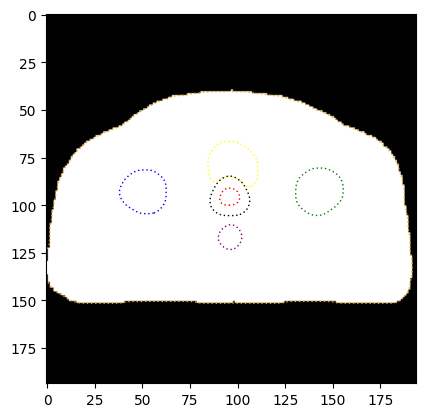

In [4]:
slice_idx = 63
plt.imshow(patient.density_image.cpu().detach().numpy()[slice_idx, :, :], cmap="gray")
for struct_name in patient.structures.keys():
    overlay_mask_outline(
        patient.structures[struct_name].cpu().detach().numpy()[slice_idx, :, :],
        color=colors[struct_name],
    )

## Define the machine, kernel table, and dose engine

A proton engine needs a commissioned **kernel table** -- depth dose and lateral sigma per energy -- rather
than the TPR and penumbra of a photon machine. `IonMachineConfig` only carries nozzle geometry.

Two engine settings are memory/accuracy knobs worth knowing: `field_size` is the beam's-eye-view window
computed around every spot (in voxels, it truncates the nuclear halo), and `n_sub_beams_per_dim` splits
each spot into `n**2` sub-beams. The defaults `(40, 40)` and `9` cost about 240 MB per spot, which does
not fit many spots on a small GPU; `(24, 24)` and `5` cost about 40 MB and are used here.


In [5]:
iso_center = (100.0, 200.0, 200.0)
sad_mm = 1000.0
prescribed_dose = 42.7
femoral_head_limit = 20.0

# Gantry angles are the only fixed part of the plan.
gantry_angles_deg = (0.0, 180.0)

patient = patient.to(device).to(dtype)

# The ion engine is handed a stopping-power-ratio volume, not an HU-derived density.
# In this water phantom the two coincide; on a real CT you need an SPR conversion.
spr = patient.density_image
dose_mask = patient.structures["External"]

machine_config = PDRT.IonMachineConfig()
table = IonKernelTable.load(
    "protons_doserad", allow_energy_interpolation=True, device=device, dtype=dtype
)
engine = PDRT.IonDoseEngine(
    machine_config=machine_config,
    kernel_table=table,
    dose_grid_spacing=patient.resolution,
    dose_grid_shape=tuple(spr.shape),
    field_size=(24, 24),
    n_sub_beams_per_dim=5,
    dtype=dtype,
    device=device,
)


## Place the spot grid

A spot only earns its place if its ray crosses the target. For every lateral position we march a ray
through the patient, integrate the stopping-power ratio into **water-equivalent depth**, and lay energy
layers across the depth range the target occupies on that ray. The energy for a layer comes from the
kernel table itself: each tabulated energy has a Bragg peak at a known depth, which inverts to
depth -> energy.

Keep `spot_spacing_mm` close to the spot sigma. Spots spaced much wider than they are large leave cold
gaps between them that no choice of weights can fill.


In [6]:
def energy_for_wet(table):
    """Interpolator from water-equivalent depth (mm) to the energy peaking there."""
    energies = np.asarray(table.available_energies, dtype=float)
    peaks = np.array([float(d[int(e.argmax())]) for d, e in
                      (table.edep_curve(float(x)) for x in energies)])
    order = np.argsort(peaks)
    return lambda wet: np.interp(wet, peaks[order], energies[order])


def plan_spots(spr, target, resolution, iso_center_mm, gantry_angles_deg, table,
               spot_spacing_mm=10.0, layer_spacing_mm=7.0, step_mm=1.0, span_mm=260.0):
    """One spot per (lateral position, energy layer) whose ray crosses the target.

    At gantry theta the beam runs along ``(cos, -sin)`` in ``(D, W)``; ``x`` is the lateral
    axis of that plane and ``y`` runs along ``H``, matching ``IonBeamletBatch.position_mm``.
    """
    spr_np = spr.detach().cpu().numpy()
    tgt_np = target.detach().cpu().numpy().astype(float)
    res_h, res_d, res_w = resolution
    iso_h, iso_d, iso_w = iso_center_mm

    idx = np.argwhere(tgt_np > 0.5)
    y_lo, y_hi = idx[:, 0].min() * res_h - iso_h, idx[:, 0].max() * res_h - iso_h
    half = 0.5 * max((idx[:, 1].max() - idx[:, 1].min()) * res_d,
                     (idx[:, 2].max() - idx[:, 2].min()) * res_w)
    ys = np.arange(y_lo, y_hi + 1e-6, spot_spacing_mm)
    xs = np.arange(-half, half + 1e-6, spot_spacing_mm)
    s = np.arange(-span_mm, span_mm, step_mm)
    wet_to_energy = energy_for_wet(table)

    angles, positions, energies = [], [], []
    for angle in gantry_angles_deg:
        theta = math.radians(angle)
        along = (math.cos(theta), -math.sin(theta))
        lateral = (math.sin(theta), math.cos(theta))
        for y in ys:
            h_idx = np.full_like(s, (iso_h + y) / res_h)
            for x in xs:
                coords = np.stack([h_idx,
                                   (iso_d + along[0] * s + lateral[0] * x) / res_d,
                                   (iso_w + along[1] * s + lateral[1] * x) / res_w])
                on_target = map_coordinates(tgt_np, coords, order=1, mode="constant") > 0.5
                if not on_target.any():
                    continue
                wet = np.cumsum(map_coordinates(spr_np, coords, order=1, mode="constant")) * step_mm
                lo, hi = wet[on_target].min(), wet[on_target].max()
                for layer in np.arange(lo, hi + 1e-6, layer_spacing_mm):
                    angles.append(angle)
                    positions.append([float(x), float(y)])
                    energies.append(float(wet_to_energy(layer)))
    return angles, positions, energies


SPOT_SIGMA_MM = 6.0

angles, positions, energies = plan_spots(
    spr, patient.structures["PTV"], patient.resolution, iso_center,
    gantry_angles_deg=gantry_angles_deg, table=table,
    spot_spacing_mm=10.0, layer_spacing_mm=7.0,
)
number_of_spots = len(angles)
print(f"{number_of_spots} spots over {len(gantry_angles_deg)} fields, "
      f"energies {min(energies):.0f}-{max(energies):.0f} MeV")

beamlets = IonBeamletBatch.create(
    gantry_angle_deg=angles,
    position_mm=positions,
    energy_mev=energies,
    sigma_mm=[[SPOT_SIGMA_MM, SPOT_SIGMA_MM]] * number_of_spots,
    weight=[1.0] * number_of_spots,
    iso_center_mm=list(iso_center),
    sad_mm=sad_mm,
    device=device,
    dtype=dtype,
)


264 spots over 2 fields, energies 108-140 MeV


## Define a progress plot

To follow the optimization, we visualize the dose distribution after every epoch.


In [7]:
def plot_progress(epoch, raw_losses, dose_pred):
    clear_output(wait=True)
    print(f"Epoch {epoch}: {[str(np.round(loss.item(), 3)) for loss in raw_losses]}")
    plot_overview(patient, dose_pred=dose_pred)


## Define the optimization objective

We optimize the spots by balancing a few simple goals:

- deliver the prescribed dose to the PTV,
- reduce dose to the rectum, bladder and femoral heads,
- suppress unnecessary dose elsewhere in the patient.

**Everything except the gantry angles is a free variable.** Each quantity is written as a smooth function
of an unconstrained tensor, so every value the engine sees is valid by construction and no clamping is
needed mid-optimization:

| variable | parameterization | why |
|---|---|---|
| weight | `scale * softplus(raw)` | a spot cannot deliver negative particles |
| position | `planned + 5 mm * tanh(raw)` | keeps spots near the grid they were planned on |
| energy | `sigmoid` into `planned ± 15 MeV` | stays inside the kernel table, keeps the layer structure |
| sigma | `sigmoid` into `[2, 15] mm` | a spot size must be positive and physical |

Energies are only differentiable because the table was loaded with `allow_energy_interpolation=True`;
without it the lookup is a hard row index and `energy_mev.grad` comes back `None`. Gantry angles never
receive a gradient -- field directions stay discrete.

The dose is summed over chunks of spots wrapped in `torch.utils.checkpoint`, so peak memory is set by
`CHUNK` rather than by the number of spots, while gradients still reach every variable.


In [8]:
CHUNK = 32          # spots in flight; peak memory scales with this, not with the spot count


def dose_from(weight, position, energy, sigma):
    """Total dose [H, D, W].

    Only the four optimised fields are swapped in; the gantry angles, isocentres
    and SAD stay as planned. `beamlet_chunk_size` makes the engine compute the
    spots in gradient-checkpointed groups, so peak memory is set by CHUNK rather
    than by the number of spots.
    """
    spots = replace(
        beamlets,
        position_mm=position,
        energy_mev=energy,
        sigma_mm=sigma,
        weight=weight,
    )
    return engine.compute_dose(spots, spr, dose_mask, beamlet_chunk_size=CHUNK)[0]


MAX_SHIFT_MM = 5.0             # how far a spot may move from its planned position
ENERGY_HALF_RANGE_MEV = 15.0   # how far its energy may move
SIGMA_MIN_MM, SIGMA_MAX_MM = 2.0, 15.0


def inverse_sigmoid(value, lo, hi):
    scaled = ((value - lo) / (hi - lo)).clamp(1e-4, 1 - 1e-4)
    return torch.log(scaled / (1.0 - scaled))


planned_position = beamlets.position_mm.detach().clone()
planned_energy = beamlets.energy_mev.detach().clone()
energy_lo = (planned_energy - ENERGY_HALF_RANGE_MEV).clamp_min(min(table.available_energies) + 1e-3)
energy_hi = (planned_energy + ENERGY_HALF_RANGE_MEV).clamp_max(max(table.available_energies) - 1e-3)

raw_weight = torch.zeros(number_of_spots, device=device, dtype=dtype, requires_grad=True)
raw_shift = torch.zeros(number_of_spots, 2, device=device, dtype=dtype, requires_grad=True)
raw_energy = inverse_sigmoid(planned_energy, energy_lo, energy_hi).clone().requires_grad_(True)
raw_sigma = inverse_sigmoid(
    torch.full((number_of_spots, 2), SPOT_SIGMA_MM, device=device, dtype=dtype),
    SIGMA_MIN_MM, SIGMA_MAX_MM,
).clone().requires_grad_(True)

WEIGHT_SCALE = 1.0


def physical_spots():
    """The free variables mapped to physical spot quantities."""
    weight = WEIGHT_SCALE * F.softplus(raw_weight)
    position = planned_position + MAX_SHIFT_MM * torch.tanh(raw_shift)
    energy = energy_lo + (energy_hi - energy_lo) * torch.sigmoid(raw_energy)
    sigma = SIGMA_MIN_MM + (SIGMA_MAX_MM - SIGMA_MIN_MM) * torch.sigmoid(raw_sigma)
    return weight, position, energy, sigma


# Start at the prescription: one unweighted pass fixes the overall particle scale.
with torch.no_grad():
    probe = dose_from(*physical_spots())
    WEIGHT_SCALE = float(prescribed_dose / probe[patient.structures["PTV"]].mean())
print(f"weight scale {WEIGHT_SCALE:.3e}")

ptv = patient.structures["PTV"]
rectum = patient.structures["Rectum"]
bladder = patient.structures["Bladder"]
femoral_heads = patient.structures["FemoralHead_L"] | patient.structures["FemoralHead_R"]

num_epochs = 5
optimizer = torch.optim.LBFGS(
    [raw_weight, raw_shift, raw_energy, raw_sigma],
    lr=1.0,                         # standard for L-BFGS; line search handles step sizing
    max_iter=20,                    # inner iterations per .step() call
    max_eval=25,                    # ~1.25 * max_iter
    tolerance_grad=1e-7,
    tolerance_change=1e-9,
    history_size=20,                # curvature pairs to keep; 10-20 is the sweet spot
    line_search_fn="strong_wolfe",  # critical - without this it's much less robust
)
last_raw_losses = None
last_dose_pred = None


def closure():
    global last_raw_losses, last_dose_pred

    optimizer.zero_grad(set_to_none=True)

    weight, position, energy, sigma = physical_spots()
    dose_pred = dose_from(weight, position, energy, sigma)

    raw_losses = [
        100.0 * torch.mean((dose_pred[ptv] - prescribed_dose) ** 2),
        upper_penalty(dose_pred[rectum], 0.5 * prescribed_dose),
        upper_penalty(dose_pred[bladder], 0.5 * prescribed_dose),
        upper_penalty(dose_pred[femoral_heads], femoral_head_limit),
        10.0 * torch.mean(dose_pred[dose_mask] ** 2),
    ]

    loss = torch.stack(raw_losses).sum()
    loss.backward()

    last_raw_losses = [l.detach().clone() for l in raw_losses]
    last_dose_pred = dose_pred.detach().clone()
    return loss


weight scale 3.704e+09


## Run the optimization

Finally, we iterate the optimizer and inspect the updated dose after each step.

This gives a compact end-to-end example of inverse planning with PyDoseRT.

Epoch 0: ['84.046', '9.72', '7.817', '0.0', '350.546']


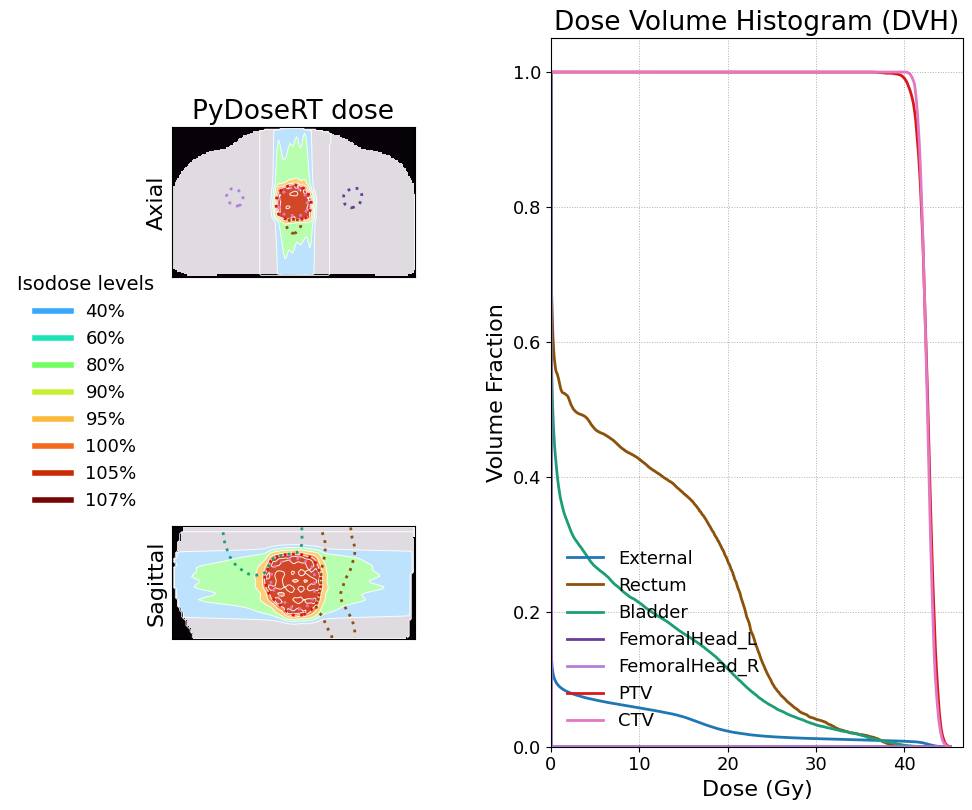

In [ ]:
for i in range(num_epochs):
    x = optimizer.step(closure)
    plot_progress(i, last_raw_losses, last_dose_pred)

## Summary

In this example, we used PyDoseRT to optimize a proton spot plan on a patient-like water phantom using
differentiable dose calculation and gradient-based updates. Spot weights, positions, energies and sizes
were all optimized together; only the gantry angles were fixed.

Two knobs dominate the result. `spot_spacing_mm` and `layer_spacing_mm` set how finely the target is
covered -- spacing much wider than the spot sigma leaves cold gaps no weighting can repair -- and
`n_sub_beams_per_dim` trades accuracy for memory and speed inside each spot.
